## **Objective of the project**
In this project we are going to perform some **classification** techniques on the *Mushroom Classification* dataset. This dataset contains more than 8000 samples about mushrooms, describing their characteristics, such as color or odor, and classifying them as poisonous or edible.
We will use these labels to assess the validity of our methods.

## **0 Preprocessing**

Notice that the preprocessing step is common for both the classification and clustering tasks. Some observations may be relevant to just one of them, nonetheless are presented in both notebooks.

In this first part, the focus is on **data preprocessing**. The main objective is to transform the original dataset into a numerical and consistent format, without using any prior information about the target variable.

The dataset contains a variable called `class`, which indicates whether a mushroom is *edible* or *poisonous*. This variable represents the ground truth label.


## 0.1 Import of Libraries

We import the Python libraries we will use in this project.

- **pandas** and **numpy** are used for data manipulation and numerical operations;
- **matplotlib** and **seaborn** are used for basic data visualization;
- **math** for mathematical operations;
- **OneHotEncoder** is used for treating the nominal features;
- **StandardScaler** will be used to normalize the data;
- **OrdinalEncoder** is used to transform the ordinal features;
- **PCA** will be used to represent visually the clusters in 2D;
- **train_test_split** is used to create the training and testing sets, useful for classification evaluation.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import math
import seaborn as sns
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.preprocessing import OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split



## 0.2 Loading the Dataset

We load the Mushroom Classification dataset.
Each row represents a single mushroom, while each column corresponds to a specific attribute describing its characteristics.

The dataset is composed of categorical variables encoded as single characters, representing the initial of the type of the attribute, according to the official UCI data description.


In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("uciml/mushroom-classification")
df = pd.read_csv(path + "/mushrooms.csv")
df.head()


Using Colab cache for faster access to the 'mushroom-classification' dataset.


,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,p,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,e,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,e,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,p,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,e,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g


### 0.3 Dataset Dimensions and Structure

In order to better understand the structure of the data, we first analyze the size and the general information of the dataset.
The dataset contains **8,124 observations** and **23 variables**.

In [3]:
df.shape


(8124, 23)

In [4]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8124 entries, 0 to 8123
Data columns (total 23 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   class                     8124 non-null   object
 1   cap-shape                 8124 non-null   object
 2   cap-surface               8124 non-null   object
 3   cap-color                 8124 non-null   object
 4   bruises                   8124 non-null   object
 5   odor                      8124 non-null   object
 6   gill-attachment           8124 non-null   object
 7   gill-spacing              8124 non-null   object
 8   gill-size                 8124 non-null   object
 9   gill-color                8124 non-null   object
 10  stalk-shape               8124 non-null   object
 11  stalk-root                8124 non-null   object
 12  stalk-surface-above-ring  8124 non-null   object
 13  stalk-surface-below-ring  8124 non-null   object
 14  stalk-color-above-ring  

### 0.4 Overview of the Variables

The dataset includes one target variable, called `class`, and several explanatory variables describing mushroom characteristics such as cap shape, odor, gill properties, stalk features, and habitat.


In [5]:
df.columns


Index(['class', 'cap-shape', 'cap-surface', 'cap-color', 'bruises', 'odor',
       'gill-attachment', 'gill-spacing', 'gill-size', 'gill-color',
       'stalk-shape', 'stalk-root', 'stalk-surface-above-ring',
       'stalk-surface-below-ring', 'stalk-color-above-ring',
       'stalk-color-below-ring', 'veil-type', 'veil-color', 'ring-number',
       'ring-type', 'spore-print-color', 'population', 'habitat'],
      dtype='object')


Below is a description of each variable included in the dataset.
- **class**: Indicates whether the mushroom is edible or poisonous  
  - *e* = edible  
  - *p* = poisonous  
- **cap-shape**: Shape of the mushroom cap (e.g. bell, conical, convex, flat)
- **cap-surface**: Surface texture of the cap (e.g. smooth, scaly, fibrous)
- **cap-color**: Color of the cap (e.g. brown, yellow, white, red)
- **bruises**: Indicates whether bruises are present on the mushroom
- **odor**: Smell of the mushroom (e.g. almond, anise, foul, none)
- **gill-attachment**: How the gills are attached to the stalk
- **gill-spacing**: Distance between gills (close or crowded)
- **gill-size**: Size of the gills (broad or narrow)
- **gill-color**: Color of the gills
- **stalk-shape**: Shape of the stalk (enlarging or tapering)
- **stalk-root**: Shape of the stalk root  
- **stalk-surface-above-ring**: Surface texture of the stalk above the ring
- **stalk-surface-below-ring**: Surface texture of the stalk below the ring
- **stalk-color-above-ring**: Color of the stalk above the ring
- **stalk-color-below-ring**: Color of the stalk below the ring
- **veil-type**: Type of veil covering the mushroom
- **veil-color**: Color of the veil
- **ring-number**: Number of rings on the stalk
- **ring-type**: Type of ring
- **spore-print-color**: Color of the spore print
- **population**: Population density of mushrooms in the area
- **habitat**: Natural habitat where the mushroom grows

All these variables are categorical and mostly nominal, therefore a suitable encoding method is required before applying clustering algorithms based on distance measures.
By the documentation found on Kaggle, we know that the variable **stalk-root**  may contain the symbol '?' indicating missing or unknown values.




##0.5 Countplots of Variables
In this section, we explore the distribution of all the categorical variables using countplots. Since they are categorical, it is not necessary to study their histograms or scatterplot.
The goal is to observe how different categories are represented in the dataset and to identify possible dominant or rare categories.
The countplot of the variable class in this analysis is only descriptive and not used in clustering.

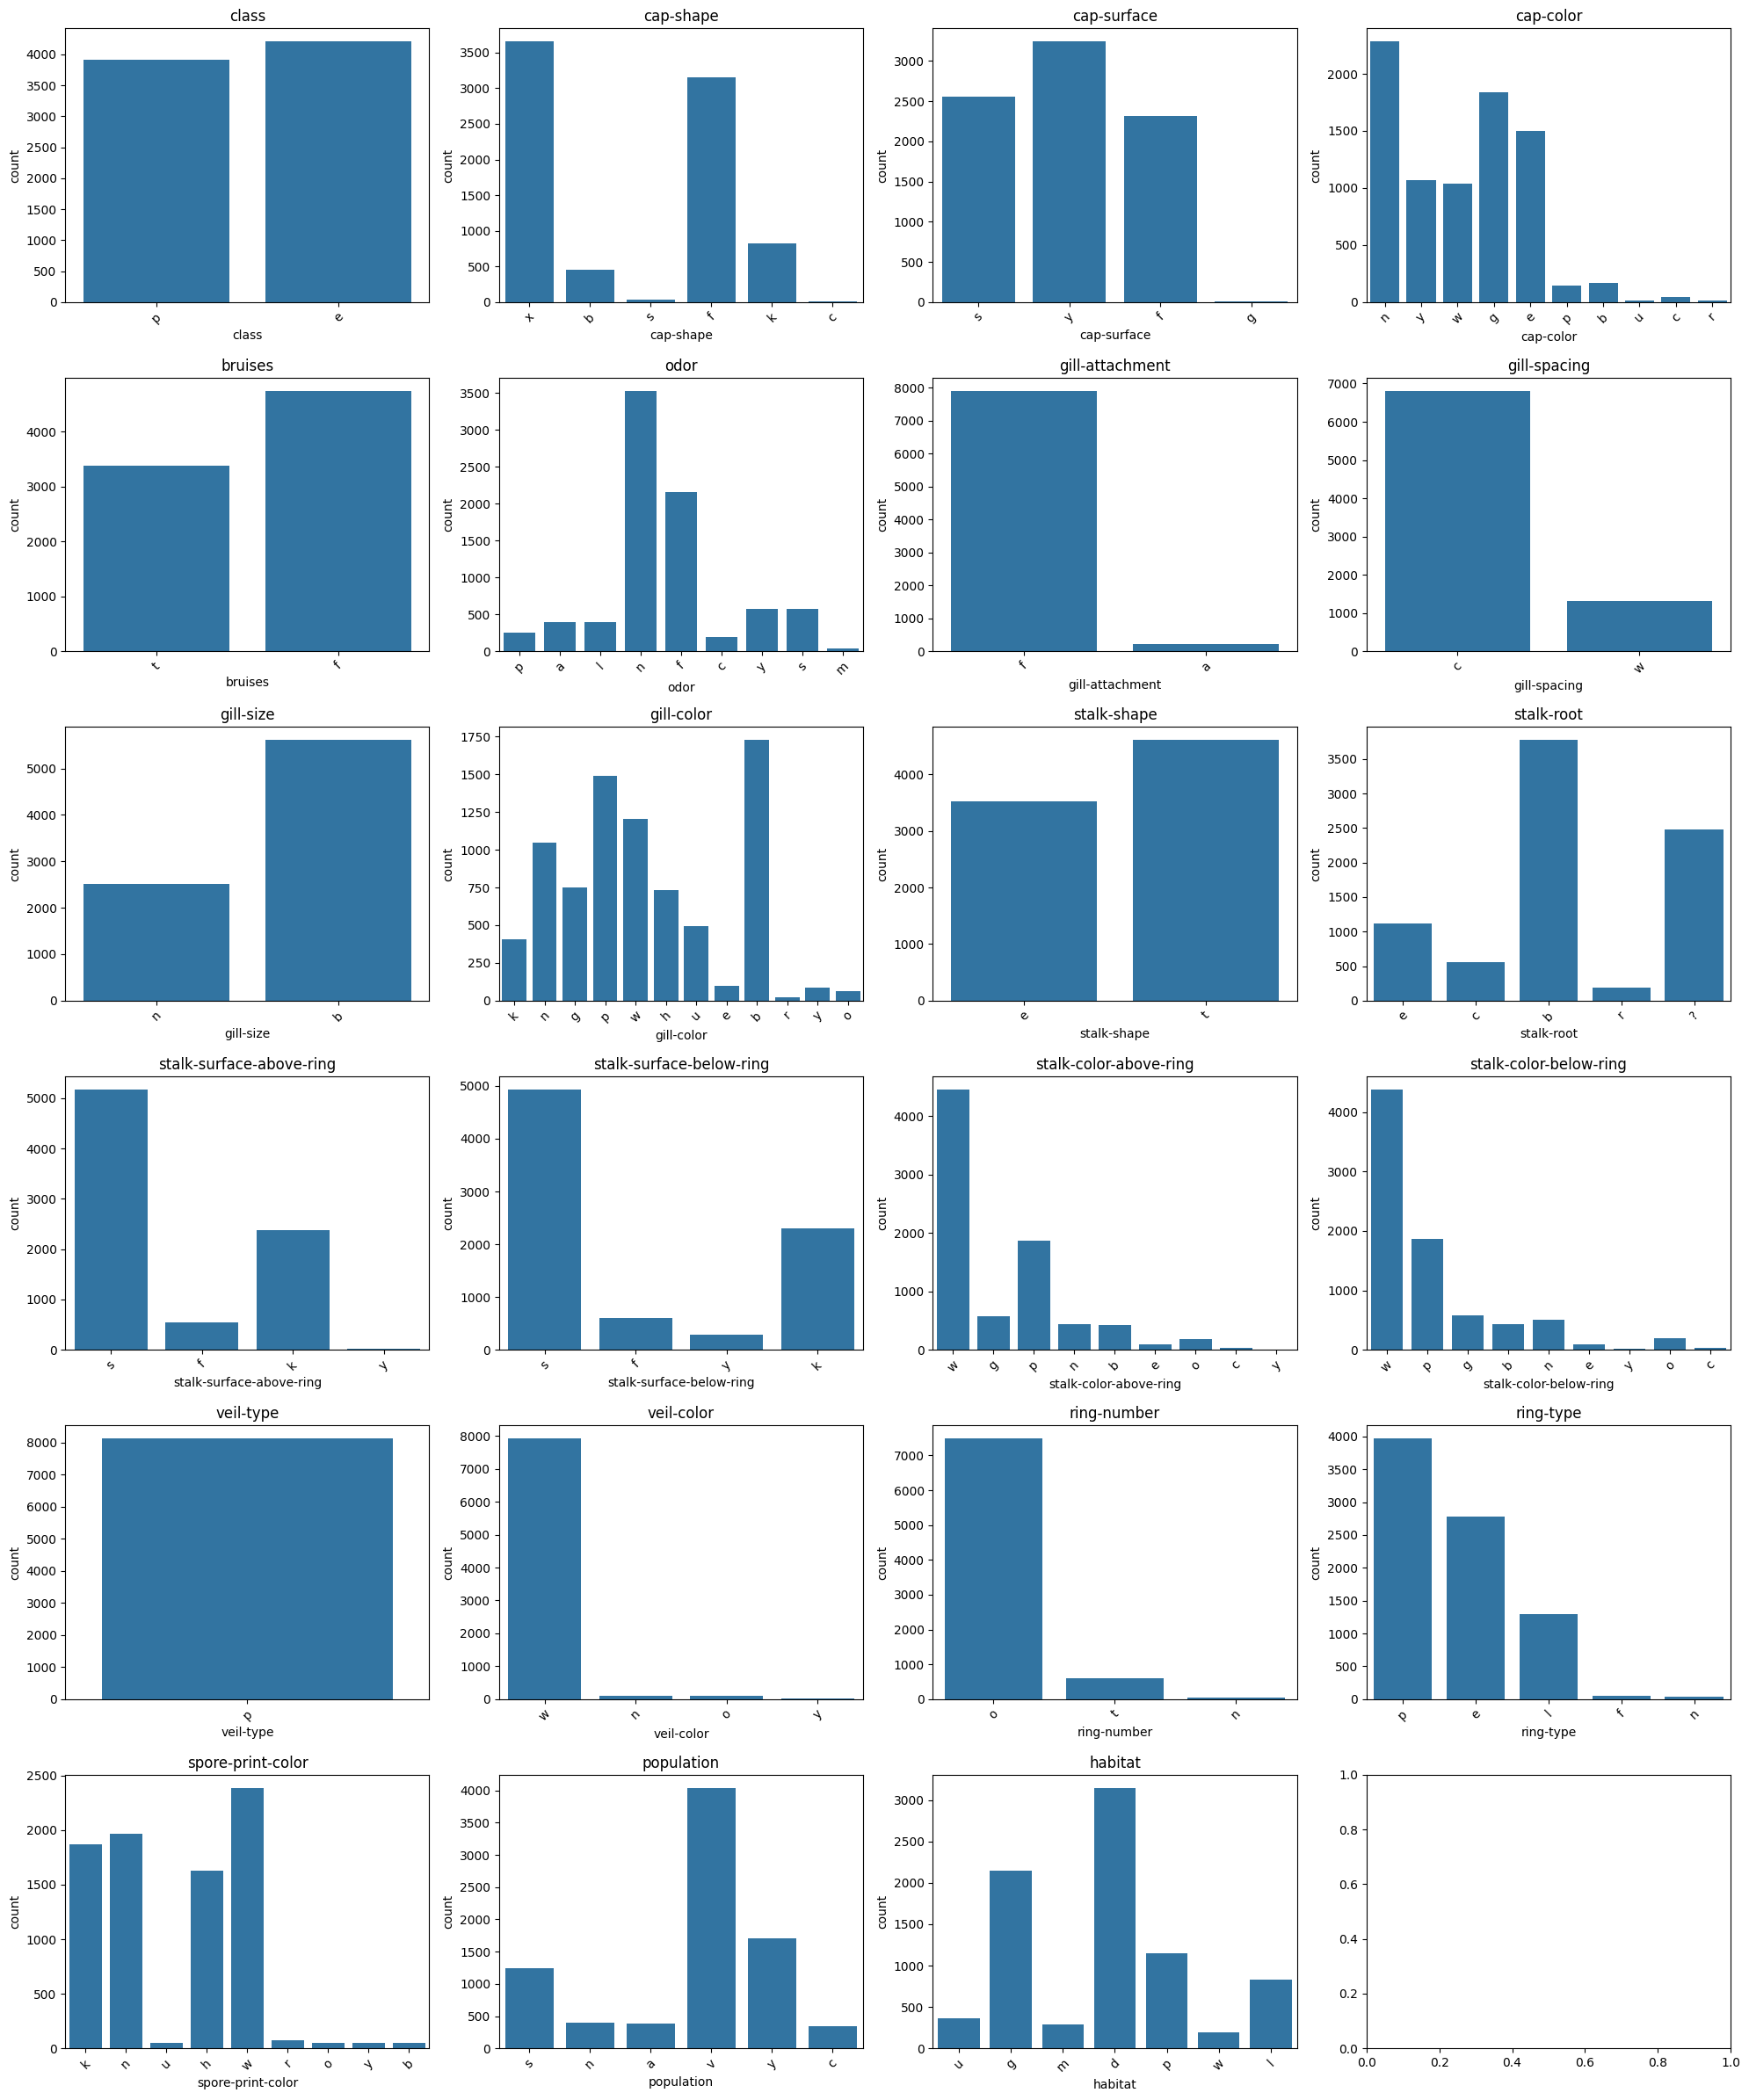

In [6]:
categorical_cols = df.columns
n_features = len(categorical_cols)
n_cols = 4
n_rows = math.ceil(n_features / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols*5, n_rows*4))
axes = axes.flatten()

for i, col in enumerate(categorical_cols):
    sns.countplot(x=col, data=df, ax=axes[i])
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()

Let us analize some of these countplots.

For the target variable `class`, which distinguishes between edible (`e`) and poisonous (`p`) mushrooms, we can say that the two classes appear to be relatively balanced in terms of frequency.  
This indicates that the dataset does not present a strong class imbalance.
A slight difference between the two classes can be observed, with edible mushrooms being marginally more frequent.

Some kinds of cap color appear much more frequently than others.  
In particular, the categories `n`, `g`, and `e` are among the most common, while several colors occur only rarely.
This indicates that the distribution of cap color is uneven, with a clear dominance of a few categories.  
Such a pattern suggests that `cap-color` may provide useful information, although some categories contribute only marginally to the overall dataset.

About `odor` most mushrooms belong to the “no odor” category.
Some odor categories may be strongly associated with specific mushroom types.

Several gill colors show relatively high frequencies, while others are much less common.  
The distribution is more spread compared to cap color, indicating greater variability across categories.
This suggests that `gill-color` captures a wider range of values and may contain relevant information for distinguishing different mushroom types.

It is interesting to observe that the variable `veil-type` has only one observed value across all samples.
Since this feature shows no variability, it does not contribute to distance computations and can be safely removed during preprocessing. Anyway we decided to keep it.

##0.6 Relationship between Features and the Target Variable

In this section, we perform an exploratory supervised analysis to investigate the relationship between some selected categorical features and the target variable class.
The objective is to understand how the distribution of feature categories differs between edible and poisonous mushrooms, and to identify variables that may be informative for classification.
It is important to note that this analysis is purely descriptive and is not used during the clustering phase. The target variable is considered here only to gain insights into the data and to support later interpretation of the clustering and classification results.

### Relationship between Odor and Class

The countplot shows the distribution of the variable `odor` across the two mushroom classes.


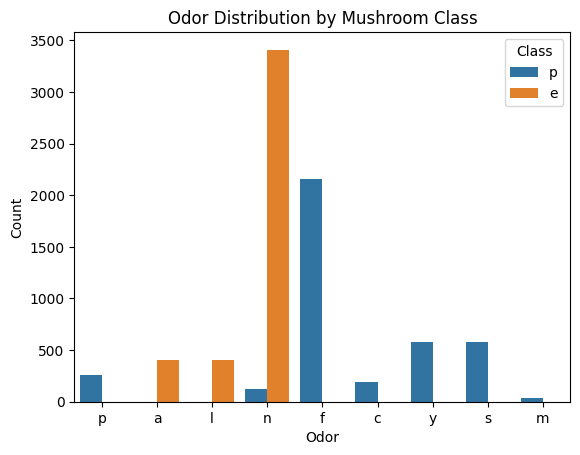

In [7]:
sns.countplot(x="odor", hue="class", data=df)

plt.title("Odor Distribution by Mushroom Class")
plt.xlabel("Odor")
plt.ylabel("Count")
plt.legend(title="Class")
plt.show()



Mushrooms with no odor (`n`) are predominantly edible, while foul odor (`f`) is mainly associated with poisonous mushrooms.  
Several odor categories appear almost exclusively in one class, indicating a strong separation between edible and poisonous mushrooms based on odor, as we noticed in the previous section.
This pattern suggests a clear association between odor and the target variable class.

### Relationship between Cap Color and Class

The countplot shows the distribution of `cap-color` across edible and poisonous mushrooms.


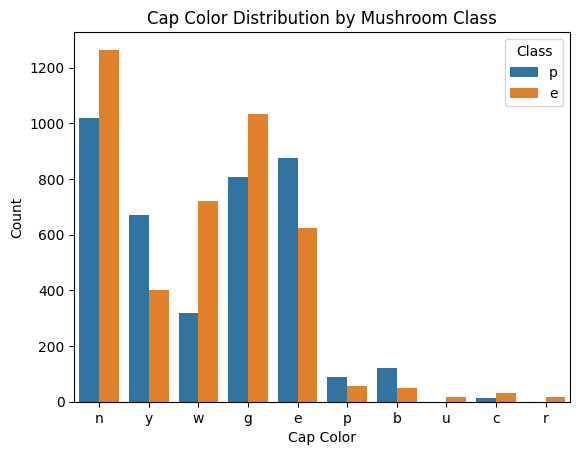

In [8]:
sns.countplot(x="cap-color", hue="class", data=df)

plt.title("Cap Color Distribution by Mushroom Class")
plt.xlabel("Cap Color")
plt.ylabel("Count")
plt.legend(title="Class")
plt.show()



For most cap colors, both classes are present, and no single color appears to be exclusively associated with one class, apart from r and u which are very rare even for their own class.  
Some colors show differences in frequency between edible and poisonous mushrooms, but the overlap between the two classes remains substantial.
Compared to the odor variable, cap color does not provide a clear separation among classes.


## 0.7 Correlation Matrix of Encoded Features

The correlation matrix shows the pairwise correlations between the one-hot encoded features.

Most correlations are close to zero, indicating a low linear dependence between the majority of encoded variables.
This result is expected, as one-hot encoding produces binary features that represent mutually exclusive categories within the same original variable.

Some localized blocks of higher positive or negative correlation can be observed.
These patterns mainly arise from the encoding structure itself, where categories belonging to the same original feature are necessarily related, but can also come from correlated features (think about the association between odor and class seen before).

Overall, the correlation matrix does not reveal strong linear relationships between features.
Its main purpose is to provide a global overview of the encoded data structure and to highlight the absence of widespread multicollinearity.



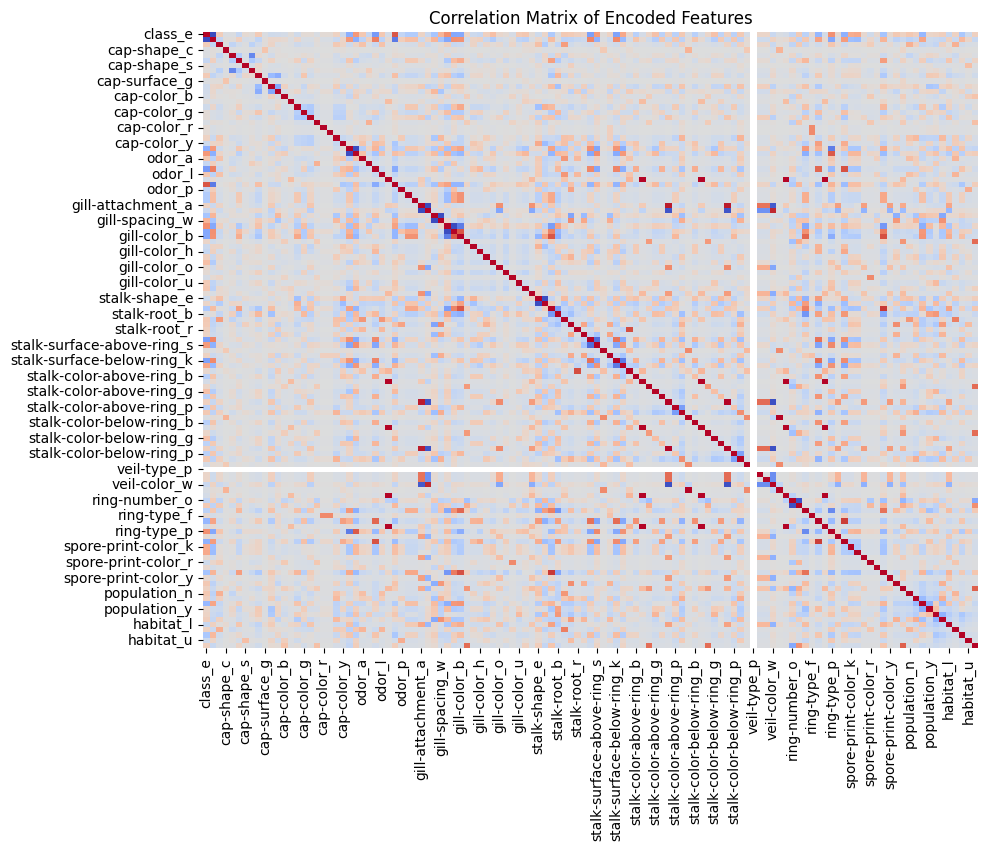

In [9]:
df_encoded = pd.get_dummies(df)
corr_matrix = df_encoded.corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, cmap="coolwarm", cbar=False)
plt.title("Correlation Matrix of Encoded Features")
plt.show()


## 0.8 Missing values
We now search for missing values inside our dataset.

In [10]:
df.isnull().any(axis=0)

,0
class,False
cap-shape,False
cap-surface,False
cap-color,False
bruises,False
odor,False
gill-attachment,False
gill-spacing,False
gill-size,False
gill-color,False


We do not seem to have any missing values.
But by the documentation, we know they may be represented by the "?" symbol, so we check for it.

In [11]:
(df == "?").any()

,0
class,False
cap-shape,False
cap-surface,False
cap-color,False
bruises,False
odor,False
gill-attachment,False
gill-spacing,False
gill-size,False
gill-color,False


In the feature stalk-root we have some missing values. Let
us see how many samples do not have any value for this feature.

In [12]:
df[df["stalk-root"]=="?"]

,class,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
3984,e,x,y,b,t,n,f,c,b,e,...,s,e,w,p,w,t,e,w,c,w
4023,p,x,y,e,f,y,f,c,n,b,...,s,w,w,p,w,o,e,w,v,p
4076,e,f,y,u,f,n,f,c,n,h,...,f,w,w,p,w,o,f,h,y,d
4100,p,x,y,e,f,y,f,c,n,b,...,s,p,p,p,w,o,e,w,v,d
4104,p,x,y,n,f,f,f,c,n,b,...,s,p,p,p,w,o,e,w,v,l
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,e,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,e,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,e,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,p,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


Since about the 30% of samples in our dataset has missing values, but just for this feature, we decide to remove the feature `stalk-root` itself.
We could already see by the countplot that "?" was the second most popular value.
Since we are working with many features, that as we already commented are not strongly correlated to this one, removing it is the best choice possible, given the high number of missing values.

In [13]:
df= df.drop(columns=["stalk-root"])
df.shape

(8124, 22)

## 0.9 Treating categorical features
As one could clearly notice by the first rows of our dataset, and as we have already underlined, all the features are categorical, meaning that they can take values only from a set of classes.
The majority of our features are nominal, i.e. there is no implied order among them (think about the different hat shapes), so for these features the one-hot encoding is the best strategy.
But regarding the *class* feature, we may interpret that as if there is an explicit order among the case edible and poisonous. It would be like ordering them based on the poisonousness level. For example we could associate to the first label the value 0 and 1 to the second one. So we treat this feature as an ordinal one.
We start to work on the latter one.






In [14]:
ordinal_encoder= OrdinalEncoder(categories=[['e','p']])
pois_level = ordinal_encoder.fit_transform(df[['class']])
pois_level= pois_level.flatten().astype(int)
df.insert(
    loc=df.columns.get_loc("class")+1,
    column="pois-level",
    value=pois_level
)
df.drop(columns="class", inplace=True)
df

,pois-level,cap-shape,cap-surface,cap-color,bruises,odor,gill-attachment,gill-spacing,gill-size,gill-color,...,stalk-surface-below-ring,stalk-color-above-ring,stalk-color-below-ring,veil-type,veil-color,ring-number,ring-type,spore-print-color,population,habitat
0,1,x,s,n,t,p,f,c,n,k,...,s,w,w,p,w,o,p,k,s,u
1,0,x,s,y,t,a,f,c,b,k,...,s,w,w,p,w,o,p,n,n,g
2,0,b,s,w,t,l,f,c,b,n,...,s,w,w,p,w,o,p,n,n,m
3,1,x,y,w,t,p,f,c,n,n,...,s,w,w,p,w,o,p,k,s,u
4,0,x,s,g,f,n,f,w,b,k,...,s,w,w,p,w,o,e,n,a,g
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,k,s,n,f,n,a,c,b,y,...,s,o,o,p,o,o,p,b,c,l
8120,0,x,s,n,f,n,a,c,b,y,...,s,o,o,p,n,o,p,b,v,l
8121,0,f,s,n,f,n,a,c,b,n,...,s,o,o,p,o,o,p,b,c,l
8122,1,k,y,n,f,y,f,c,n,b,...,k,w,w,p,w,o,e,w,v,l


Now we study all the other features.

In [15]:
nominal_features = ["cap-shape", "cap-surface", "cap-color", "bruises", "odor",
    "gill-attachment", "gill-spacing", "gill-size", "gill-color",
    "stalk-shape", "stalk-surface-above-ring", "stalk-surface-below-ring",
    "stalk-color-above-ring", "stalk-color-below-ring",
    "veil-type", "veil-color", "ring-number", "ring-type",
    "spore-print-color", "population", "habitat"]

nom_encoder = OneHotEncoder()
nom_features = nom_encoder.fit_transform(df[nominal_features])
nom_features = nom_features.toarray()
nom_features = pd.DataFrame(nom_features,columns=nom_encoder.get_feature_names_out(nominal_features),index=df.index)
nom_features = nom_features.astype(int)
df = pd.concat([df[["pois-level"]], nom_features],axis=1)

df


,pois-level,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
0,1,0,0,0,0,0,1,0,0,1,...,1,0,0,0,0,0,0,0,1,0
1,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
2,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,1,0,0,0
3,1,0,0,0,0,0,1,0,0,0,...,1,0,0,0,0,0,0,0,1,0
4,0,0,0,0,0,0,1,0,0,1,...,0,0,0,0,1,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8119,0,0,0,0,1,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
8120,0,0,0,0,0,0,1,0,0,1,...,0,1,0,0,0,1,0,0,0,0
8121,0,0,0,1,0,0,0,0,0,1,...,0,0,0,0,0,1,0,0,0,0
8122,1,0,0,0,1,0,0,0,0,0,...,0,1,0,0,0,1,0,0,0,0


## 0.10 Splitting the dataset
The last part of this preprocessing stage is to divide our dataset into a training and a test set, that we will use respectively for training and evaluating our models.

In [16]:
target = "pois-level"

#for clustering
X = df.drop(columns=[target])
y = df[target]

#for classification
train_data, test_data, train_labels, test_labels = train_test_split(X, y, test_size=0.25, shuffle=True, random_state=102, stratify=y)
train_data

,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_k,cap-shape_s,cap-shape_x,cap-surface_f,cap-surface_g,cap-surface_s,cap-surface_y,...,population_s,population_v,population_y,habitat_d,habitat_g,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w
3022,0,0,1,0,0,0,1,0,0,0,...,0,0,1,1,0,0,0,0,0,0
3748,0,0,1,0,0,0,1,0,0,0,...,0,1,0,1,0,0,0,0,0,0
3528,0,0,1,0,0,0,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
1534,0,0,1,0,0,0,1,0,0,0,...,1,0,0,0,1,0,0,0,0,0
3175,0,0,0,0,0,1,0,0,0,1,...,0,1,0,1,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1269,0,0,0,0,0,1,0,0,0,1,...,0,0,1,1,0,0,0,0,0,0
144,0,0,0,0,0,1,0,0,0,1,...,0,0,0,0,1,0,0,0,0,0
6164,0,0,0,0,0,1,0,0,1,0,...,0,1,0,1,0,0,0,0,0,0
5619,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,1


##**1 Classification**
We now focus on the classification task, i.e. we aim to create a model which can correctly predict if a mushroom is poisonous or edible, after being trained on a subset of our dataset.
To achieve this, we will train and evaluate several different classification models.

Notice that for testing the goodness of our models we will use accuracy, which is fine since the dataset is balanced as observed at the beginning. For the same reason we avoid methods such as RIPPER, since it is more suited for imbalanced classes, and will only focus on standard classifiers.

We collect here all the libraries used.

In [17]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score
from sklearn.tree import DecisionTreeClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC


## 1.1 KNN

The first technique we test is the K-Nearest-Neighbors algorithm, a lazy learner method which memorizes the dataset and then classifies new samples based on the behaviour of their k nearest neighbors inside the dataset.
It works best with normalized data, therefore let us normalize both the training and testing set created before.

In [18]:
scaler = StandardScaler()
train_data = scaler.fit_transform(train_data)
test_data = scaler.transform(test_data)

In [19]:
knn_1 = KNeighborsClassifier(n_neighbors=1)
knn_1.fit(train_data, train_labels)

train_acc_1 = accuracy_score(train_labels, knn_1.predict(train_data))
test_acc_1 = accuracy_score(test_labels, knn_1.predict(test_data))

print("KNN (k=1) - Train accuracy:", train_acc_1)
print("KNN (k=1) - Test accuracy:", test_acc_1)

KNN (k=1) - Train accuracy: 1.0
KNN (k=1) - Test accuracy: 1.0


The training accuracy is equal to 1, which doesn't surprise us since each training sample is classified based on its nearest neighbor, which is itself. The second result may initially appear suspicious, but nonetheless it doesn't indicate data leakage, since the standardization was done separately between training and testing sets. The observed performance can be explained by the intrinsic characteristics of the dataset, which exhibits a very strong class separability.
For sake of completness we use again this method, increasing the number of neighbors.

In [20]:
knn_15 = KNeighborsClassifier(n_neighbors=15)
knn_15.fit(train_data, train_labels)

train_acc_15 = accuracy_score(train_labels, knn_15.predict(train_data))
test_acc_15 = accuracy_score(test_labels, knn_15.predict(test_data))

print("KNN (k=15) - Train accuracy:", train_acc_15)
print("KNN (k=15) - Test accuracy:", test_acc_15)

KNN (k=15) - Train accuracy: 0.9988511406532086
KNN (k=15) - Test accuracy: 0.999507631708518


As expected, increasing k introduces additional smoothing in the decision boundary, slightly reducing the training accuracy while maintaining very high performance on the test set.

##Overfitting
To show what happens when we increase the number of neighbors, we plot the validation curve. As the number of neighbors goes up, the training accuracy of our model goes down. We are moving from an overfitting situation to an underfitting one.
The parameter range is chosen to span from very low to relatively large values of k, allowing us to observe the full bias–variance trade-off without excessive computational cost.

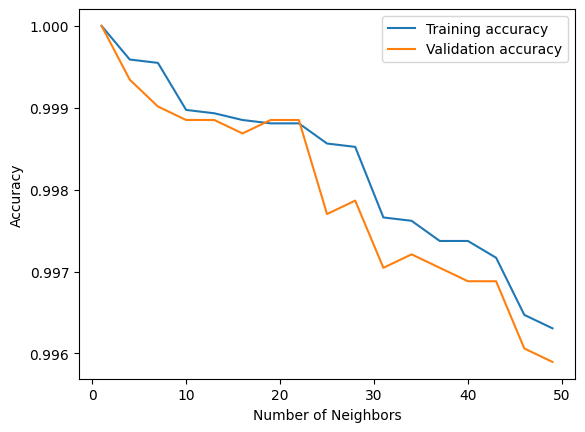

In [21]:
from sklearn.model_selection import validation_curve

param_range = np.arange(1, 52, 3)

train_scores, test_scores = validation_curve(
    KNeighborsClassifier(),
    train_data, train_labels,
    param_name="n_neighbors",
    param_range=param_range,
    cv=5
)

plt.plot(param_range, train_scores.mean(axis=1), label="Training accuracy")
plt.plot(param_range, test_scores.mean(axis=1), label="Validation accuracy")
plt.xlabel("Number of Neighbors")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

## 1.2 Decision Tree
Another possible classifier is a Decision Tree. At first we do not fix the maximum depth of this Tree.

In [22]:
tree = DecisionTreeClassifier(max_depth=None, random_state=42)
tree.fit(train_data, train_labels)

print("Train accuracy:", accuracy_score(train_labels, tree.predict(train_data)))
print("Test accuracy:", accuracy_score(test_labels, tree.predict(test_data)))

Train accuracy: 1.0
Test accuracy: 1.0


Allowing the Tree to grow without costraints can lead to overfitting, as indicated by the 100% training accuracy, since the model may fit the noise. Let us fix this problem by imposing a maximum depth.

In [23]:
small_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
small_tree.fit(train_data,train_labels)

print("Train accuracy:", accuracy_score(train_labels, small_tree.predict(train_data)))
print("Test accuracy:", accuracy_score(test_labels, small_tree.predict(test_data)))

Train accuracy: 0.9652059740686033
Test accuracy: 0.966518956179222


Reducing the depth may be leading to an underfitting situation, since the variance is reduced but the bias increases. In fact increasing the depth makes our Decision Tree more complex, so it can adapt to small noises in the data and therefore increase its variance.

##Confusion matrix
Instead of using the accuracy score, we can analyse the confusion matrix.

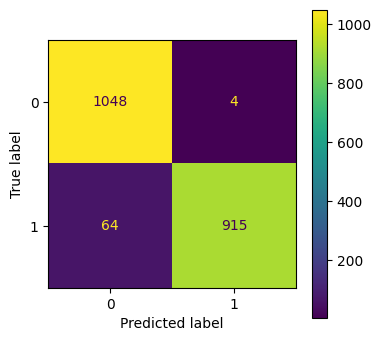

In [24]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
cmp = ConfusionMatrixDisplay(confusion_matrix(test_labels, small_tree.predict(test_data)))
fig, ax = plt.subplots(figsize=(4, 4))
cmp.plot(ax=ax)
plt.show()

The points along the diagonal are the corrected classified points. We see that there are some false negative samples, which in our case means that they were classified as edible even if they are not. Still, the majority of the mushrooms is correctly classified.

If we wish to show a report of the validation measures, we can use the Classification report.

In [25]:
from sklearn.metrics import classification_report
print(classification_report(test_labels, small_tree.predict(test_data)))

              precision    recall  f1-score   support

           0       0.94      1.00      0.97      1052
           1       1.00      0.93      0.96       979

    accuracy                           0.97      2031
   macro avg       0.97      0.97      0.97      2031
weighted avg       0.97      0.97      0.97      2031



We can try and tune better the hyperparameters for the Decision Tree with the following code:

In [26]:
from sklearn.model_selection import GridSearchCV
param_grid = {
    'max_depth': [3, 5, None],
    'min_samples_split': [2, 5, 10],
    'min_samples_leaf': [1, 2, 4],
    'criterion': ['gini', 'entropy']
}
grid_search = GridSearchCV(DecisionTreeClassifier(random_state=42), param_grid, cv=5)
grid_search.fit(train_data, train_labels)
print("Best parameters:", grid_search.best_params_)
best_tree = grid_search.best_estimator_
print("Train accuracy:", accuracy_score(train_labels, best_tree.predict(train_data)))
print("Test accuracy:", accuracy_score(test_labels, best_tree.predict(test_data)))

Best parameters: {'criterion': 'gini', 'max_depth': None, 'min_samples_leaf': 2, 'min_samples_split': 2}
Train accuracy: 1.0
Test accuracy: 1.0


## 1.3 Naive-Bayes

This method achieves very high accuracy on both the training and test sets, with very similar values.  
This indicates that the model generalizes well and does not show signs of overfitting.




In [27]:
nb = GaussianNB()
nb.fit(train_data, train_labels)

train_acc = accuracy_score(train_labels, nb.predict(train_data))
test_acc = accuracy_score(test_labels, nb.predict(test_data))

print("Naive Bayes - Train accuracy:", train_acc)
print("Naive Bayes - Test accuracy:", test_acc)


Naive Bayes - Train accuracy: 0.9891678975873953
Naive Bayes - Test accuracy: 0.9886755292959133


##Cross validation on Naive-Bayes

The cross-validation results show a mean accuracy of approximately 0.87, which is lower than the accuracy obtained on the single train-test split.  
This is expected, because cross-validation evaluates the model on different data splits, leading to a more realistic estimate of its generalization performance.



The relatively high standard deviation indicates that the performance of Naive Bayes varies across different folds.  
This suggests that the model is sensitive to the specific data partition and that some subsets of the data are easier to classify than others.

Overall, while Naive Bayes performs extremely well on a single split, cross-validation reveals that its performance is slightly less stable when evaluated across multiple folds.


In [28]:
from sklearn.model_selection import cross_val_score
import numpy as np

nb = GaussianNB()

cv_scores = cross_val_score(nb, X, y, cv=5, scoring='accuracy')

print("Naive Bayes CV accuracies:", cv_scores)
print("Mean CV accuracy:", np.mean(cv_scores))
print("Std CV accuracy:", np.std(cv_scores))


Naive Bayes CV accuracies: [0.85538462 0.95938462 0.99507692 0.90338462 0.64100985]
Mean CV accuracy: 0.8708481242895036
Std CV accuracy: 0.12441453240954088


## 1.4 SVM

Support Vector Machines (SVM) are applied as a more powerful classification method, capable of modeling non-linear decision boundaries.  
An RBF kernel is used, which allows the classifier to capture complex relationships between the features.


The SVM model achieves perfect accuracy on both the training and test sets.  
This suggests that the classes in the dataset are highly separable and that SVM is able to learn an effective decision boundary.



In [29]:
svm = SVC(kernel='rbf', random_state=42)
svm.fit(train_data, train_labels)

train_acc_svm = accuracy_score(train_labels, svm.predict(train_data))
test_acc_svm = accuracy_score(test_labels, svm.predict(test_data))

print("SVM - Train accuracy:", train_acc_svm)
print("SVM - Test accuracy:", test_acc_svm)


SVM - Train accuracy: 1.0
SVM - Test accuracy: 1.0


##Conclusions
Overall, all the methods here presented give good results. The dataset itself seems to be well suited for a classification task, with classes clearly separable.